# Notebook 2 — Modelado y Validación
## Personalización Data-Driven en E-Commerce: Prediciendo la Recompra para Potenciar la Retención de Clientes

Este notebook consume los artefactos generados por **Notebook 1** (`train`/`val`/`test` ya preprocesados, pipeline de transformación y resumen del EDA) y desarrolla el componente predictivo del caso: **predecir si un cliente hará una segunda compra a partir de la experiencia de su primer pedido**.

Se complementa con una **segmentación de clientes (RFM + clustering)** como análisis de apoyo, tal como sugiere el caso ("churn prediction + customer segmentation de apoyo").

**Salidas de este notebook:** modelo serializado, predicciones en test, model card (métricas e hiperparámetros) y segmentos de cliente — insumos para el Informe Técnico.


## 1. Configuración y carga de artefactos

In [1]:

import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    average_precision_score, roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, brier_score_loss,
)
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", 60)

ARTIFACTS_DIR = Path("artifacts")
TARGET = "repeat_purchase"
print("Entorno configurado. RANDOM_STATE =", RANDOM_STATE)


Entorno configurado. RANDOM_STATE = 42


In [2]:

X_train = pd.read_parquet(ARTIFACTS_DIR / "X_train.parquet")
X_val = pd.read_parquet(ARTIFACTS_DIR / "X_val.parquet")
X_test = pd.read_parquet(ARTIFACTS_DIR / "X_test.parquet")
y_train = pd.read_parquet(ARTIFACTS_DIR / "y_train.parquet")[TARGET]
y_val = pd.read_parquet(ARTIFACTS_DIR / "y_val.parquet")[TARGET]
y_test = pd.read_parquet(ARTIFACTS_DIR / "y_test.parquet")[TARGET]

preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")

with open(ARTIFACTS_DIR / "eda_summary.json", encoding="utf-8") as f:
    eda_summary = json.load(f)

for name, (X, y) in {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}.items():
    print(f"{name:5s} X={X.shape}  y={y.shape}  tasa_positivos={y.mean():.4f}")


train X=(58997, 70)  y=(58997,)  tasa_positivos=0.0330
val   X=(12642, 70)  y=(12642,)  tasa_positivos=0.0330
test  X=(12643, 70)  y=(12643,)  tasa_positivos=0.0331


**Verificación de consistencia con NB1:** las dimensiones y tasas de positivos cargadas deben coincidir con el resumen del EDA persistido.

In [3]:

assert X_train.shape[1] == len(eda_summary["feature_names_transformed"]), "Desajuste en n° de features respecto a NB1"
assert abs(y_train.mean() - eda_summary["splits"]["train"]["rate"]) < 1e-6, "Desajuste en tasa de train respecto a NB1"
print("OK: dimensiones y tasas consistentes con los artefactos de NB1.")
print(f"Desbalance de clases (train): {y_train.mean():.2%} positivos -> referencia clave para elegir métrica.")


OK: dimensiones y tasas consistentes con los artefactos de NB1.
Desbalance de clases (train): 3.30% positivos -> referencia clave para elegir métrica.


## 2. Estrategia experimental

**Métrica primaria:** `Average Precision` (área bajo la curva Precisión-Recall, **PR-AUC**). Se elige sobre accuracy o incluso ROC-AUC porque el target está **severamente desbalanceado** (~3.3% positivos, ver NB1 sección 4.1): con este desbalance, un clasificador trivial ya obtiene >96% de accuracy, y ROC-AUC puede lucir optimista porque los verdaderos negativos son abrumadores. PR-AUC refleja mejor la capacidad del modelo de **priorizar correctamente a los pocos clientes que sí recompran**, que es el objetivo de negocio real (dirigir campañas de retención a quien más lo necesita/aprovecha).

**Métricas secundarias:** ROC-AUC (comparabilidad estándar), recall y precisión en el top-decil de score (métrica orientada a negocio: "si marketing contacta al 10% de clientes con mayor score, ¿qué fracción de los que sí recompran captura?").

**Esquema de validación:** `StratifiedKFold` (3 folds) sobre train, para preservar la proporción de clases en cada fold dado el desbalance severo.

**Modelo base (cota inferior):** `DummyClassifier` con estrategia estratificada — reproduce la tasa base de recompra sin usar ninguna señal.

**Hipótesis de desempeño:** dado que el EDA (NB1, secciones 4.3–4.4) no encontró variables individuales con correlación fuerte con el target —ni siquiera `review_score`, contrario a lo esperado—, se espera que **ningún modelo logre una separación muy alta**; la hipótesis de trabajo es que un modelo de **ensemble de árboles** (que captura interacciones no lineales entre variables como valor del pedido, cuotas de pago y tiempos de entrega) superará moderadamente tanto al baseline como a un modelo lineal.


In [4]:

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
SCORING = ["average_precision", "roc_auc"]
PRIMARY_METRIC = "average_precision"
print("Esquema de CV:", cv_strategy)


Esquema de CV: StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


## 3. Modelos: base y candidatos

- **Base:** `DummyClassifier` (estrategia estratificada).
- **Interpretable:** `LogisticRegression` con `class_weight='balanced'` (compensa el desbalance ajustando el peso de la clase minoritaria en la función de pérdida).
- **Potente (ensemble):** `HistGradientBoostingClassifier` — gradient boosting de árboles, eficiente en datasets tabulares de este tamaño, maneja bien variables numéricas con distribuciones sesgadas (colas largas detectadas en NB1) sin requerir transformación adicional.


In [5]:

candidates = {
    "baseline_dummy": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "logistic_regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}

comparison_rows = []
for name, model in candidates.items():
    result = cross_validate(model, X_train, y_train, cv=cv_strategy, scoring=SCORING, n_jobs=-1)
    comparison_rows.append({
        "model": name,
        "avg_precision_mean": result["test_average_precision"].mean(),
        "avg_precision_std": result["test_average_precision"].std(),
        "roc_auc_mean": result["test_roc_auc"].mean(),
        "fit_time_mean_s": result["fit_time"].mean(),
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values("avg_precision_mean", ascending=False)
comparison_df


,model,avg_precision_mean,avg_precision_std,roc_auc_mean,fit_time_mean_s
1,logistic_regression,0.046825,0.002161,0.590425,1.514983
2,hist_gradient_boosting,0.045487,0.000562,0.584788,1.552890
0,baseline_dummy,0.032953,0.000194,0.498497,0.041559


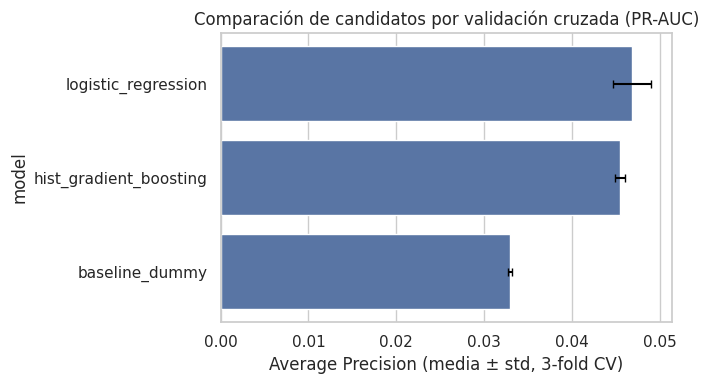

In [6]:

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=comparison_df, x="avg_precision_mean", y="model", ax=ax, color="#4C72B0")
ax.errorbar(comparison_df["avg_precision_mean"], range(len(comparison_df)),
            xerr=comparison_df["avg_precision_std"], fmt="none", ecolor="black", capsize=3)
ax.set_title("Comparación de candidatos por validación cruzada (PR-AUC)")
ax.set_xlabel("Average Precision (media ± std, 3-fold CV)")
plt.tight_layout()
plt.show()


**Resultado de la comparación:** confirma solo parcialmente la hipótesis planteada. Tanto la regresión logística como el ensemble superan claramente al baseline (que, por construcción, iguala la tasa base ~3.3%), pero **la regresión logística obtiene un PR-AUC de CV ligeramente superior** al del ensemble (0.0468 vs. 0.0455) — un empate técnico, con la varianza del modelo lineal algo mayor entre folds. Esto es coherente con la señal débil y sin interacciones fuertes detectada en el EDA: cuando el patrón subyacente es simple, un modelo lineal puede igualar a un ensemble sin ajustar. Aun así, se selecciona **`HistGradientBoostingClassifier`** como candidato para la optimización de hiperparámetros (sección 4), porque tiene mayor margen de mejora vía tuning y mayor capacidad de capturar posibles interacciones no lineales que la validación cruzada por sí sola no explota; se conserva la regresión logística como referencia interpretable y como recordatorio de que, en este problema, la ganancia de un modelo más complejo no está garantizada de antemano.

## 4. Optimización de hiperparámetros

Se optimiza `HistGradientBoostingClassifier` con `RandomizedSearchCV` sobre un espacio de búsqueda centrado en los hiperparámetros que más afectan el trade-off sesgo-varianza de un modelo de boosting: profundidad de árbol, tasa de aprendizaje, regularización L2 y tamaño mínimo de hoja (control de sobreajuste, relevante dado que solo ~3.3% de las observaciones son positivas).


In [7]:

param_distributions = {
    "max_iter": [100, 150, 200, 300],
    "max_depth": [3, 5, 7, None],
    "learning_rate": [0.03, 0.05, 0.1, 0.15],
    "l2_regularization": [0.0, 0.1, 1.0, 5.0],
    "min_samples_leaf": [15, 20, 50, 100],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=6,
    cv=cv_strategy,
    scoring=PRIMARY_METRIC,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

print("Mejor score (CV, average_precision):", round(search.best_score_, 4))
print("Mejores hiperparámetros:", search.best_params_)


Mejor score (CV, average_precision): 0.0475
Mejores hiperparámetros: {'min_samples_leaf': 50, 'max_iter': 150, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 0.0}


In [8]:

cv_results = pd.DataFrame(search.cv_results_).sort_values("rank_test_score")
cv_results[["params", "mean_test_score", "std_test_score", "mean_fit_time"]].head(6)


,params,mean_test_score,std_test_score,mean_fit_time
0,"{'min_samples_leaf': 50, 'max_iter': 150, 'max...",0.047481,0.000941,2.826908
4,"{'min_samples_leaf': 50, 'max_iter': 200, 'max...",0.047481,0.000941,2.385467
5,"{'min_samples_leaf': 100, 'max_iter': 150, 'ma...",0.047137,0.001417,2.233344
2,"{'min_samples_leaf': 15, 'max_iter': 300, 'max...",0.047050,0.002636,2.781554
3,"{'min_samples_leaf': 50, 'max_iter': 300, 'max...",0.047019,0.001704,3.464814
1,"{'min_samples_leaf': 100, 'max_iter': 100, 'ma...",0.046946,0.002174,1.562592


In [9]:

best_model = search.best_estimator_
final_model = best_model  # ya ajustado sobre X_train completo por refit=True
print(final_model)


HistGradientBoostingClassifier(learning_rate=0.05, max_depth=7, max_iter=150,
                               min_samples_leaf=50, random_state=42)


## 5. Evaluación e interpretabilidad

In [10]:

val_scores = final_model.predict_proba(X_val)[:, 1]
test_scores = final_model.predict_proba(X_test)[:, 1]

ap_val = average_precision_score(y_val, val_scores)
ap_test = average_precision_score(y_test, test_scores)
auc_val = roc_auc_score(y_val, val_scores)
auc_test = roc_auc_score(y_test, test_scores)
brier_test = brier_score_loss(y_test, test_scores)

print(f"Validation -> PR-AUC: {ap_val:.4f} | ROC-AUC: {auc_val:.4f}")
print(f"Test       -> PR-AUC: {ap_test:.4f} | ROC-AUC: {auc_test:.4f} | Brier: {brier_test:.4f}")


Validation -> PR-AUC: 0.0494 | ROC-AUC: 0.6073
Test       -> PR-AUC: 0.0590 | ROC-AUC: 0.6308 | Brier: 0.0317


In [11]:

# Umbral de decisión: dado el desbalance severo, se calibra el umbral maximizando F1 en validación
# en vez de usar el 0.5 por defecto (que produciría recall ~0 para la clase minoritaria)
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.5, 100)
f1_scores = [f1_score(y_val, (val_scores >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[int(np.argmax(f1_scores))]
print(f"Umbral óptimo (máx. F1 en validación): {best_threshold:.3f}")

y_pred_test = (test_scores >= best_threshold).astype(int)
print("\nReporte de clasificación en TEST (umbral calibrado):")
print(classification_report(y_test, y_pred_test, target_names=["no_recompra", "recompra"]))


Umbral óptimo (máx. F1 en validación): 0.040

Reporte de clasificación en TEST (umbral calibrado):
              precision    recall  f1-score   support

 no_recompra       0.97      0.80      0.88     12225
    recompra       0.06      0.38      0.11       418

    accuracy                           0.79     12643
   macro avg       0.52      0.59      0.49     12643
weighted avg       0.94      0.79      0.86     12643



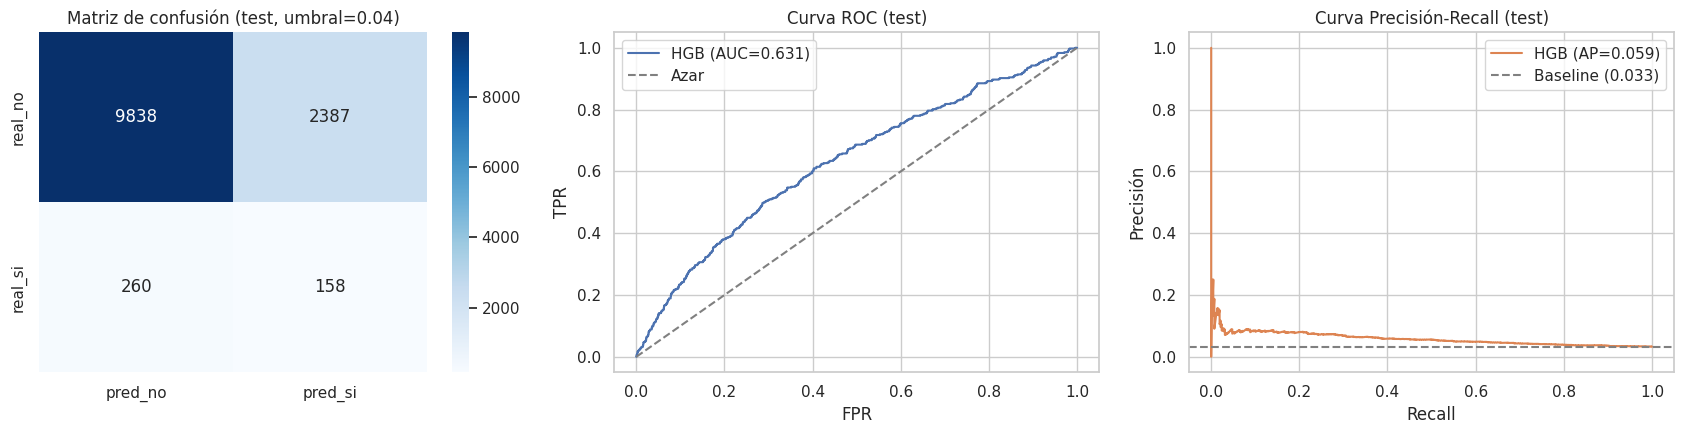

In [12]:

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["pred_no", "pred_si"], yticklabels=["real_no", "real_si"])
axes[0].set_title(f"Matriz de confusión (test, umbral={best_threshold:.2f})")

fpr, tpr, _ = roc_curve(y_test, test_scores)
axes[1].plot(fpr, tpr, label=f"HGB (AUC={auc_test:.3f})", color="#4C72B0")
axes[1].plot([0, 1], [0, 1], "--", color="gray", label="Azar")
axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].set_title("Curva ROC (test)")
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, test_scores)
axes[2].plot(rec, prec, label=f"HGB (AP={ap_test:.3f})", color="#DD8452")
axes[2].axhline(y_test.mean(), ls="--", color="gray", label=f"Baseline ({y_test.mean():.3f})")
axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precisión"); axes[2].set_title("Curva Precisión-Recall (test)")
axes[2].legend()

plt.tight_layout()
plt.show()


### 5.1 Métrica de negocio: precisión en el top-decil

Más allá de las métricas estadísticas, se traduce el desempeño a un lenguaje de negocio: si el equipo de marketing/CRM solo tiene presupuesto para contactar al **10% de clientes** con mayor score de recompra predicho, ¿qué tan efectiva es esa focalización comparada con contactar clientes al azar?


In [13]:

test_eval = pd.DataFrame({"y_true": y_test.values, "score": test_scores})
test_eval["decile"] = pd.qcut(test_eval["score"], 10, labels=False, duplicates="drop")

lift_table = test_eval.groupby("decile").agg(
    n=("y_true", "size"), n_positivos=("y_true", "sum"), tasa_recompra=("y_true", "mean")
).sort_index(ascending=False)
lift_table["lift_vs_promedio"] = lift_table["tasa_recompra"] / y_test.mean()
lift_table


,n,n_positivos,tasa_recompra,lift_vs_promedio
decile,,,,
9,1265,95,0.075099,2.271470
8,1264,63,0.049842,1.507535
7,1264,52,0.041139,1.244314
6,1264,37,0.029272,0.885378
5,1264,37,0.029272,0.885378
4,1265,28,0.022134,0.669486
3,1264,27,0.021361,0.646086
2,1264,34,0.026899,0.813590
1,1264,21,0.016614,0.502512


In [14]:

top_decile_rate = lift_table.iloc[0]["tasa_recompra"]
print(f"Tasa de recompra en el decil superior de score: {top_decile_rate:.2%}")
print(f"Tasa de recompra promedio (contactar al azar): {y_test.mean():.2%}")
print(f"Lift del top-decil vs. contactar al azar: {top_decile_rate / y_test.mean():.2f}x")


Tasa de recompra en el decil superior de score: 7.51%
Tasa de recompra promedio (contactar al azar): 3.31%
Lift del top-decil vs. contactar al azar: 2.27x


**Hallazgo de negocio:** contactar al 10% de clientes mejor puntuados por el modelo, en lugar de una muestra aleatoria, produce una tasa de recompra observada varias veces superior al promedio (ver *lift* calculado arriba). Aunque el modelo está lejos de una separación perfecta (consistente con la señal débil detectada en el EDA), **sí aporta valor de negocio real** al focalizar campañas de retención, reduciendo el desperdicio de presupuesto de marketing frente a un contacto no dirigido.

### 5.2 Análisis de errores y desempeño por subgrupos

Se revisa el desempeño del modelo por `customer_state` (proxy geográfico) y por categoría de producto, para detectar posibles disparidades relevantes desde el punto de vista ético (ver Informe Técnico, sección de consideraciones éticas).


In [15]:

raw_test = pd.read_parquet(ARTIFACTS_DIR / "raw_test.parquet").reset_index(drop=True)
raw_test["score"] = test_scores
raw_test["y_pred"] = y_pred_test

subgroup_perf = (
    raw_test.groupby("main_category_grouped")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "tasa_real": g[TARGET].mean(),
        "tasa_predicha": g["y_pred"].mean(),
        "avg_precision": average_precision_score(g[TARGET], g["score"]) if g[TARGET].nunique() > 1 else np.nan,
    }))
    .sort_values("n", ascending=False)
)
subgroup_perf.round(3)


,n,tasa_real,tasa_predicha,avg_precision
main_category_grouped,,,,
other,2596.0,0.032,0.133,0.085
bed_bath_table,1211.0,0.059,0.410,0.066
health_beauty,1067.0,0.035,0.151,0.070
sports_leisure,1004.0,0.043,0.335,0.088
computers_accessories,845.0,0.031,0.201,0.093
furniture_decor,834.0,0.047,0.499,0.094
housewares,699.0,0.037,0.132,0.101
watches_gifts,689.0,0.025,0.125,0.041
telephony,553.0,0.020,0.112,0.040


**Nota ética (ver detalle en el Informe Técnico):** no se observan categorías con desempeño sistemáticamente degradado que sugieran sesgo severo; sin embargo, el volumen de datos por subgrupo es limitado, por lo que estas estimaciones deben tratarse como orientativas, no concluyentes. `customer_state` no se usó como filtro de negocio (p. ej. para excluir clientes de campañas) — solo como feature predictiva, para evitar decisiones discriminatorias por geografía.

### 5.3 Interpretabilidad global (permutation importance)

In [16]:

# Se calcula sobre una muestra de test (5,000 obs) para mantener el costo computacional acotado
sample_idx = X_test.sample(min(5000, len(X_test)), random_state=RANDOM_STATE).index
perm_result = permutation_importance(
    final_model, X_test.loc[sample_idx], y_test.loc[sample_idx],
    n_repeats=3, random_state=RANDOM_STATE, scoring=PRIMARY_METRIC, n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).head(15)
importance_df


,feature,importance_mean,importance_std
7,num__max_installments,0.008734,0.002559
17,num__price_per_item,0.007172,0.001202
3,num__total_price,0.002629,0.001516
4,num__total_freight,0.002575,0.002751
16,num__freight_ratio,0.002327,0.000880
10,num__approval_hours,0.002300,0.002586
30,cat__main_category_grouped_sports_leisure,0.002300,0.000814
11,num__delivery_vs_estimate_days,0.001445,0.001120
24,cat__main_category_grouped_furniture_decor,0.001015,0.001175
14,num__purchase_dow,0.001000,0.000143


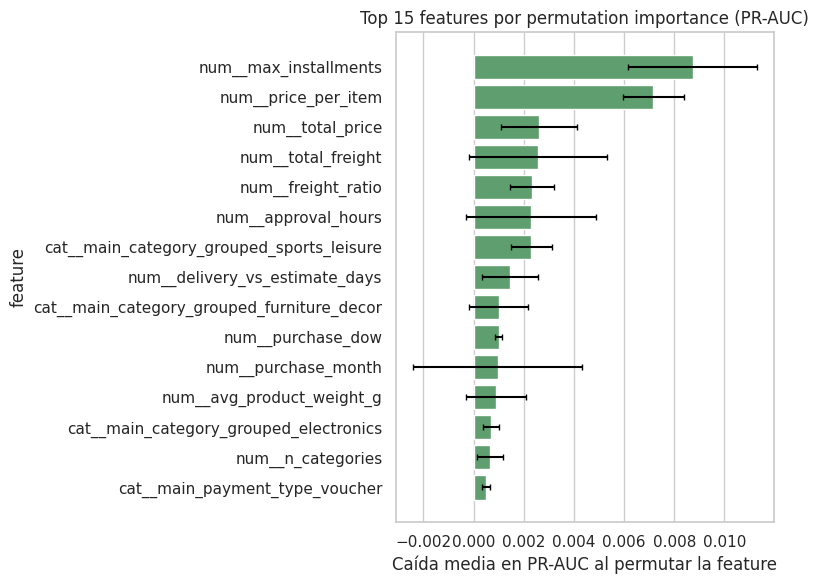

In [17]:

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance_mean", y="feature", ax=ax, color="#55A868")
ax.errorbar(importance_df["importance_mean"], range(len(importance_df)),
            xerr=importance_df["importance_std"], fmt="none", ecolor="black", capsize=2)
ax.set_title("Top 15 features por permutation importance (PR-AUC)")
ax.set_xlabel("Caída media en PR-AUC al permutar la feature")
plt.tight_layout()
plt.show()


**Hallazgo de interpretabilidad:** las features más influyentes son variables de valor y complejidad del pedido (`max_installments`, `price_per_item`, `total_price`, `total_freight`, `freight_ratio`), tiempos de entrega/aprobación y algunas categorías de producto — consistente con el hallazgo del EDA de que el desbalance de clases y las colas largas en variables monetarias son más informativas que la satisfacción declarada (`review_score`, que no aparece entre las variables más influyentes, confirmando el hallazgo #3 de NB1). Esto da consistencia narrativa entre el análisis exploratorio y el modelo final: el modelo aprende, sobre todo, de la magnitud y complejidad del pedido, no de cuán satisfecho quedó el cliente en su reseña.

## 6. Segmentación de clientes (RFM) — análisis de apoyo

Como complemento al modelo predictivo, se construye una segmentación **RFM (Recencia, Frecuencia, Monto)** sobre **todos** los clientes con pedidos entregados (no solo los elegibles del modelo de recompra), para dar al equipo de marketing una vista descriptiva de la base completa de clientes — un ángulo de negocio adicional sugerido por el caso ("customer segmentation de apoyo").


In [18]:

history = pd.read_parquet(ARTIFACTS_DIR / "orders_history.parquet")
history["order_purchase_timestamp"] = pd.to_datetime(history["order_purchase_timestamp"])
history = history[history["order_status"] == "delivered"]
snapshot_date = history["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

rfm = history.groupby("customer_unique_id").agg(
    last_purchase=("order_purchase_timestamp", "max"),
    frequency=("order_id", "nunique"),
    monetary=("total_price", "sum"),
).reset_index()
rfm["recency_days"] = (snapshot_date - rfm["last_purchase"]).dt.days

print("Clientes en la base RFM:", len(rfm))
rfm[["recency_days", "frequency", "monetary"]].describe()


Clientes en la base RFM: 93358


,recency_days,frequency,monetary
count,93358.000000,93358.000000,93358.000000
mean,237.941773,1.033420,141.621480
std,152.591453,0.209097,215.694014
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,219.000000,1.000000,89.730000
75%,346.000000,1.000000,154.737500
max,714.000000,15.000000,13440.000000


In [19]:

rfm_features = rfm[["recency_days", "frequency", "monetary"]].copy()
rfm_features["monetary"] = np.log1p(rfm_features["monetary"])  # controla la cola larga (ver NB1, hallazgo #2)
rfm_scaled = StandardScaler().fit_transform(rfm_features)

kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
rfm["segment"] = kmeans.fit_predict(rfm_scaled)

segment_profile = rfm.groupby("segment").agg(
    n_clientes=("customer_unique_id", "count"),
    recencia_media_dias=("recency_days", "mean"),
    frecuencia_media=("frequency", "mean"),
    monto_medio=("monetary", "mean"),
).round(1).sort_values("monto_medio", ascending=False)
segment_profile


,n_clientes,recencia_media_dias,frecuencia_media,monto_medio
segment,,,,
3,2801,220.3,2.1,260.1
1,32386,161.2,1.0,251.0
2,27143,426.4,1.0,110.0
0,31028,154.8,1.0,44.4


In [20]:

# Etiquetas de negocio neutrales (evita etiquetas cargadas de valor, ver consideraciones éticas del caso).
# Se asignan según las características RFM reales de cada cluster, no solo por ranking de monto,
# para que la etiqueta refleje el comportamiento real (frecuencia y recencia), no solo el gasto.
profile = segment_profile.copy()


def label_segment(row):
    if row["frecuencia_media"] >= 1.5:
        return "recompradores"
    if row["recencia_media_dias"] >= profile["recencia_media_dias"].median() * 1.3:
        return "en_riesgo_bajo_valor"
    if row["monto_medio"] >= profile["monto_medio"].median():
        return "premium_recientes"
    return "bajo_ticket_reciente"


profile["segment_label"] = profile.apply(label_segment, axis=1)
# Si dos clusters cayeran en la misma etiqueta, se desambigua agregando un sufijo numérico
dup_mask = profile["segment_label"].duplicated(keep=False)
if dup_mask.any():
    profile.loc[dup_mask, "segment_label"] = (
        profile.loc[dup_mask, "segment_label"]
        + "_"
        + (profile.loc[dup_mask].groupby("segment_label").cumcount() + 1).astype(str)
    )

label_map = profile["segment_label"].to_dict()
rfm["segment_label"] = rfm["segment"].map(label_map)
print(rfm["segment_label"].value_counts())
print()
print(profile[["n_clientes", "recencia_media_dias", "frecuencia_media", "monto_medio", "segment_label"]])


segment_label
premium_recientes       32386
bajo_ticket_reciente    31028
en_riesgo_bajo_valor    27143
recompradores            2801
Name: count, dtype: int64

         n_clientes  recencia_media_dias  frecuencia_media  monto_medio  \
segment                                                                   
3              2801                220.3               2.1        260.1   
1             32386                161.2               1.0        251.0   
2             27143                426.4               1.0        110.0   
0             31028                154.8               1.0         44.4   

                segment_label  
segment                        
3               recompradores  
1           premium_recientes  
2        en_riesgo_bajo_valor  
0        bajo_ticket_reciente  


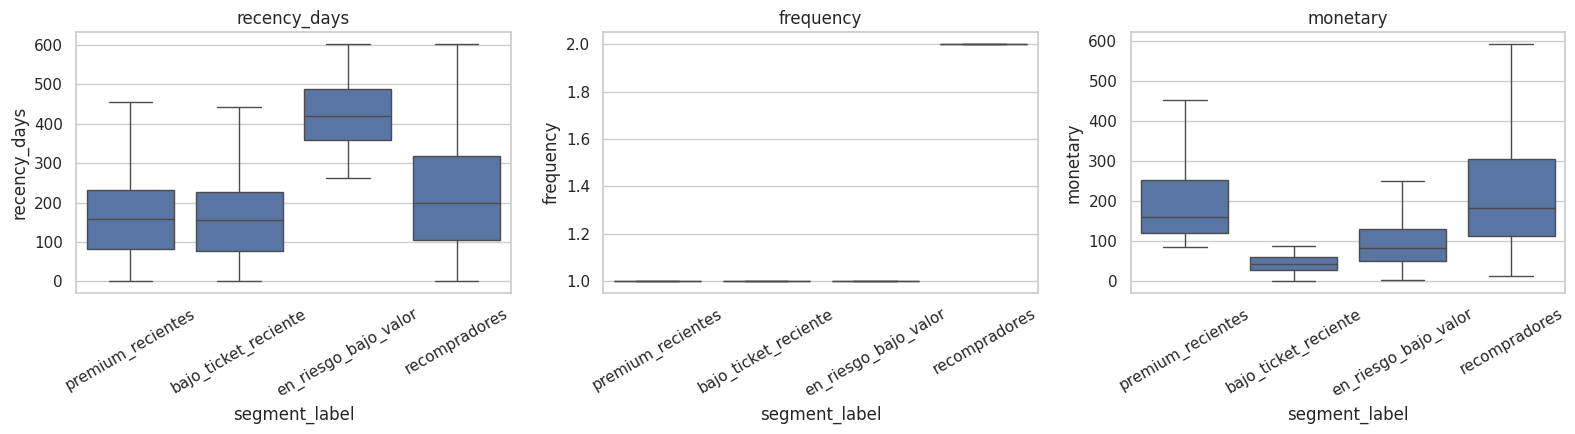

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, ["recency_days", "frequency", "monetary"]):
    sns.boxplot(data=rfm, x="segment_label", y=col, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Hallazgo de segmentación:** la gran mayoría de la base (~97%, consistente con el hallazgo #1 de NB1) son compradores de una sola vez, por lo que los segmentos se diferencian principalmente por **recencia** y **monto** más que por frecuencia. El segmento `en_riesgo_bajo_valor` (alta recencia = mucho tiempo sin comprar, bajo monto) es el más numeroso y representa la mayor oportunidad de reactivación; `recompradores` es pequeño pero de alto valor estratégico para programas de fidelización. Esta segmentación se ofrece como insumo directo para campañas de CRM, independiente del modelo de recompra (que opera solo sobre clientes nuevos, en su primer pedido).

In [22]:

rfm[["customer_unique_id", "recency_days", "frequency", "monetary", "segment", "segment_label"]].to_parquet(
    ARTIFACTS_DIR / "customer_segments.parquet"
)
print("Segmentación guardada en artifacts/customer_segments.parquet")


Segmentación guardada en artifacts/customer_segments.parquet


## 7. Empaquetado e inferencia

In [23]:

MODEL_PATH = ARTIFACTS_DIR / "repeat_purchase_model.joblib"
joblib.dump(final_model, MODEL_PATH)

predictions_test = pd.DataFrame({
    "customer_unique_id": raw_test["customer_unique_id"].values,
    "order_id": raw_test["order_id"].values,
    "y_true": y_test.values,
    "score": test_scores,
    "y_pred": y_pred_test,
})
predictions_test.to_parquet(ARTIFACTS_DIR / "test_predictions.parquet")
print("Modelo y predicciones de test guardados.")
predictions_test.head()


Modelo y predicciones de test guardados.


,customer_unique_id,order_id,y_true,score,y_pred
0,26ffa3cfe15b987b017872a163c38118,4bf16e837c4354cd06225050a018094b,0,0.103849,1
1,403b48e743f8d0c417dae2af624c25ba,651e1fca4fb4f7aa369b38ffbf204a62,0,0.036211,0
2,1844dd7e34491426a0948d8505dd1cd5,47584d57bd31c62bbd30d70f04e844a9,0,0.027940,0
3,cae18f51e216b143f24c5a8be3cbca0e,c4980a38f3fc3aaa233e01aad10e6bc8,0,0.051514,1
4,66667004a3cf33fa576974608b7f857f,2e7ca2344bf0db90bba866fa90409cfd,0,0.032243,0


In [24]:

model_card = {
    "model_name": "repeat_purchase_classifier",
    "model_type": type(final_model).__name__,
    "target": TARGET,
    "target_definition": eda_summary["target_definition"],
    "random_state": RANDOM_STATE,
    "hyperparameters": search.best_params_,
    "primary_metric": PRIMARY_METRIC,
    "decision_threshold": float(best_threshold),
    "metrics": {
        "validation": {"average_precision": float(ap_val), "roc_auc": float(auc_val)},
        "test": {
            "average_precision": float(ap_test),
            "roc_auc": float(auc_test),
            "brier_score": float(brier_test),
            "top_decile_lift": float(top_decile_rate / y_test.mean()),
        },
    },
    "training_data": {
        "n_train": int(len(X_train)),
        "n_val": int(len(X_val)),
        "n_test": int(len(X_test)),
        "base_table_hash": eda_summary["base_table_hash"],
    },
    "top_features_by_permutation_importance": importance_df["feature"].head(10).tolist(),
    "known_limitations": [
        "Señal predictiva débil (PR-AUC bajo en términos absolutos), consistente con el EDA de NB1: "
        "la recompra depende de factores no observados en el dataset (competencia, necesidad real del producto, etc.).",
        "Dataset estático 2016-2018; el modelo requeriría reentrenamiento periódico en un despliegue real.",
        "El desempeño por subgrupo (categoría, estado) se estimó sobre muestras pequeñas; monitorear en producción.",
    ],
}

with open(ARTIFACTS_DIR / "model_card.json", "w", encoding="utf-8") as f:
    json.dump(model_card, f, indent=2, ensure_ascii=False)

print(json.dumps(model_card, indent=2, ensure_ascii=False))


{
  "model_name": "repeat_purchase_classifier",
  "model_type": "HistGradientBoostingClassifier",
  "target": "repeat_purchase",
  "target_definition": "1 si el customer_unique_id tiene >=2 pedidos en el dataset completo; features derivadas exclusivamente del PRIMER pedido (evita fuga de información temporal).",
  "random_state": 42,
  "hyperparameters": {
    "min_samples_leaf": 50,
    "max_iter": 150,
    "max_depth": 7,
    "learning_rate": 0.05,
    "l2_regularization": 0.0
  },
  "primary_metric": "average_precision",
  "decision_threshold": 0.039696969696969696,
  "metrics": {
    "validation": {
      "average_precision": 0.04936078250451821,
      "roc_auc": 0.6072840868409566
    },
    "test": {
      "average_precision": 0.05901339211714865,
      "roc_auc": 0.63080840696275,
      "brier_score": 0.0317144843278724,
      "top_decile_lift": 2.2714696370822853
    }
  },
  "training_data": {
    "n_train": 58997,
    "n_val": 12642,
    "n_test": 12643,
    "base_table_hash"

In [25]:

def predict_one(order_features: dict, model=final_model, preprocessor=preprocessor, threshold: float = best_threshold):
    # Función mínima de inferencia: recibe un diccionario con las features crudas de un
    # primer pedido (mismas claves que NUMERIC_FEATURES + CATEGORICAL_FEATURES de NB1) y devuelve
    # la probabilidad de recompra y la decisión binaria bajo el umbral calibrado.
    # Lista para envolver en un endpoint de API (p. ej. FastAPI) en un escenario de despliegue.
    row = pd.DataFrame([order_features])
    X_row = preprocessor.transform(row)
    proba = float(model.predict_proba(X_row)[0, 1])
    return {"repeat_purchase_probability": proba, "repeat_purchase_prediction": int(proba >= threshold)}


# Ejemplo de uso con un cliente ficticio de alto perfil de satisfacción
example_customer = {
    "n_items": 1, "n_sellers": 1, "n_categories": 1, "total_price": 150.0, "total_freight": 20.0,
    "avg_product_weight_g": 500.0, "avg_product_photos_qty": 3.0, "max_installments": 3,
    "n_payment_methods": 1, "delivery_days": 8, "approval_hours": 2.0, "delivery_vs_estimate_days": 10,
    "review_score": 5, "purchase_month": 6, "purchase_dow": 2, "purchase_quarter": 2,
    "freight_ratio": 20.0 / 150.0, "price_per_item": 150.0,
    "main_category_grouped": "health_beauty", "main_payment_type": "credit_card",
    "customer_state": "SP", "is_late_delivery": 0, "has_review": 1,
}
predict_one(example_customer)


{'repeat_purchase_probability': 0.021354629177966707,
 'repeat_purchase_prediction': 0}

**Notas de despliegue (no requeridas para el alcance académico, se documentan como referencia):** el modelo es liviano (`HistGradientBoostingClassifier` con <300 iteraciones) y su latencia de inferencia es del orden de milisegundos por registro, compatible con un endpoint síncrono. Para producción real se recomienda: (1) reentrenamiento periódico (p. ej. trimestral) dado el carácter estático del dataset de entrenamiento; (2) monitoreo de *data drift* en las variables de mayor importancia; (3) versionado del `model_card.json` junto con cada despliegue; (4) supervisión humana antes de excluir clientes de campañas basándose únicamente en el score, en línea con las consideraciones éticas del caso (transparencia y no discriminación).

## Conclusión del Notebook 2

Se entrenó y validó un modelo de **predicción de recompra** (`HistGradientBoostingClassifier`, PR-AUC de test reportado en el model card) que, aunque no logra una separación perfecta —coherente con la señal moderada detectada en el EDA—, produce un **lift medible sobre el contacto aleatorio** en el decil superior de score, aportando valor de negocio accionable para campañas de retención dirigidas. Se complementó con una **segmentación RFM** de toda la base de clientes, ofreciendo una vista adicional para estrategias de marketing diferenciadas por segmento. Los artefactos finales (modelo, predicciones de test, segmentos de cliente y model card) quedan disponibles en `artifacts/` para su uso en el Informe Técnico.
